In [5]:
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpyro as npr
import numpyro.distributions as dist
import corner
from numpyro.infer import MCMC, NUTS
from scipy.special import roots_legendre
from jax.scipy.stats import gaussian_kde
from numpyro.handlers import condition # for fixing parameters in model
import pandas as pd

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
def nth_order_quad(n=20):
    xval, weights = map(jnp.array, roots_legendre(n))
    xval = xval.reshape(-1, 1)
    weights = weights.reshape(-1, 1)

    def integrate(func, a, b, args=()):
        # Integrate function with args from a to b
        return 0.5 * (b - a) * jnp.sum(
            weights * func(0.5 * ((b - a) * xval + (b + a)), *args),
            axis=0
        )

    return integrate
quad = nth_order_quad() # jax compatible quad function for integration


#functions for calculating beta
def E(z, w_0, w_a, OmM):
    return jnp.sqrt(OmM*(1+z)**3 + (1-OmM)*(1+z)**(3*(1+w_0+w_a))*jnp.exp((-3*w_a*z)/(1+z)))

def integral(z_i, z_j, w_0, w_a, OmM):
    integrant = lambda z: 1.0 / E(z, w_0, w_a, OmM)
    return quad(integrant, z_i, z_j)

def b(z_l, z_s1, z_s2, w_0, w_a, OmM):
    return (integral(z_l, z_s1, w_0, w_a, OmM)*integral(0, z_s2, w_0, w_a, OmM)/
            (integral(z_l, z_s2, w_0, w_a, OmM)*integral(0, z_s1, w_0, w_a, OmM))
    )

#for reading DESI data
def read_txt(filename, column):
    data = []
    with open(filename, "r") as f:
        for line in f:
            values = line.strip().split()
            data.append(values[column-1])
    return np.array(data[1:], dtype=float)

In [8]:
w_0_desi = read_txt("desi/w0wa.chain.1.txt", 3)
w_a_desi = read_txt("desi/w0wa.chain.1.txt", 4)
OmM_desi = read_txt("desi/w0wa.chain.1.txt", 6)

w_0_desi_std = np.std(w_0_desi)
w_a_desi_std = np.std(w_a_desi)
OmM_desi_std = np.std(OmM_desi)

In [9]:
desi_dist = dist.MultivariateNormal(
    jnp.array([jnp.mean(OmM_desi), jnp.mean(w_0_desi), jnp.mean(w_a_desi)]),
    jnp.array(jnp.cov(jnp.vstack([OmM_desi, w_0_desi, w_a_desi])))
)

def joint_model(z_l, z_s1, z_s2, beta, sig_b):
    w_0 = npr.sample('w_0', dist.Uniform(-3, 1))
    w_a = npr.sample('w_a', dist.Uniform(-3, 2))
    OmM = npr.sample('OmM', dist.Uniform(0, 1))

    model_beta = npr.deterministic("b", b(z_l, z_s1, z_s2, w_0, w_a, OmM))

    # O(1) per step, no double-counting — just condition the sampler
    log_desi = desi_dist.log_prob(jnp.array([OmM, w_0, w_a]))
    npr.deterministic("log_desi", log_desi)
    npr.factor("desi_likelihood_factor", log_desi)

    # measured_beta is precomputed outside, passed in as argument
    measured_error_beta = beta * sig_b
    npr.sample('likelihood', dist.Normal(model_beta, measured_error_beta), obs=beta)

defuncted, use for moving zs2 and sig_b incrementally

In [10]:
'''
records = []

def run(start: float, end: float, step: float, lens:float=0.222, s1:float=0.609, sample=10000):
    z_l = lens
    z_s1 = s1
    z_s2_range = np.arange(start, end, step)
    axis_range = [(0, 1), (-3.0, 1.0), (-3.0, 2.0)]

    if start <= z_s1:
        print("read idiot")
        return

    name = NUTS(joint_model)
    mcmc = MCMC(name, num_warmup=5000, num_samples=sample, num_chains=1)
    key = jax.random.PRNGKey(100)

    for z_s2 in z_s2_range:
        beta = float(jnp.squeeze(b(z_l, z_s1, z_s2, -1.0, 0.0, 0.3)))

        for sig_b in np.arange(0.005, 0.056, 0.01):
            mcmc.run(key, z_l, z_s1, z_s2, beta, sig_b)

            # posterior samples are already DESI-conditioned — no reweighting needed
            w_0_samples = mcmc.get_samples()['w_0']
            w_a_samples = mcmc.get_samples()['w_a']
            OmM_samples = mcmc.get_samples()['OmM']

            records.append({
                'z_l': z_l,
                'z_s1':z_s1,
                'z_s2': z_s2,
                'sig_b': sig_b,
                'beta': float(mcmc.get_samples()['b'].mean()),
                'w0_sigma': float(jnp.std(w_0_samples) / w_0_desi_std),
                'wa_sigma': float(jnp.std(w_a_samples) / w_a_desi_std),
                'OmM_sigma': float(jnp.std(OmM_samples) / OmM_desi_std),
                'w0_mean': float(jnp.mean(w_0_samples)),
                'wa_mean': float(jnp.mean(w_a_samples)),
                'OmM_mean': float(jnp.mean(OmM_samples)),
            })


            desi = corner.corner(
                np.array([OmM_desi, w_0_desi, w_a_desi]).T,
                labels=[r"$\Omega_M$", r"$w_0$", r"$w_a$"], 
                color = "grey",
                plot_contours=True,
                contour_kwargs={"linewidths": 2, "alpha": 1},
                levels=[0.3935, 0.8647, 0.9889],
                plot_density = False,
                plot_datapoints = False,
                fill_contours=False,
                show_titles=False,
                range=axis_range
            )

            joint = corner.corner(
                np.array([OmM_samples, w_0_samples, w_a_samples]).T,
                labels=[r"$\Omega_M$", r"$w_0$", r"$w_a$"], 
                color = "black",
                plot_contours=True,
                contour_kwargs={"linewidths": [2, 2.2, 2.4], "alpha": 1},
                levels=[0.3935, 0.8647, 0.9889],
                plot_density = False,
                plot_datapoints = False,
                fill_contours=False,
                range=axis_range,
                show_titles=True,
                fig=desi
            )

            #plt.suptitle(f'z_l={z_l:.2f}  z_s1={z_s1:.2f}  z_s2={z_s2:.2f}', y=1, fontsize=14)
            plt.savefig(f"w0wa_corner/zs2={z_s2},sig_b={sig_b}.png")
            plt.close()
'''

<>:1: SyntaxWarning: invalid escape sequence '\O'
<>:1: SyntaxWarning: invalid escape sequence '\O'
/var/folders/_n/r_6tbbrn3jd1nn364_ty0xnm0000gn/T/ipykernel_52249/1535243849.py:1: SyntaxWarning: invalid escape sequence '\O'
  '''


'\nrecords = []\n\ndef run(start: float, end: float, step: float, lens:float=0.222, s1:float=0.609, sample=10000):\n    z_l = lens\n    z_s1 = s1\n    z_s2_range = np.arange(start, end, step)\n    axis_range = [(0, 1), (-3.0, 1.0), (-3.0, 2.0)]\n\n    if start <= z_s1:\n        print("read idiot")\n        return\n\n    name = NUTS(joint_model)\n    mcmc = MCMC(name, num_warmup=5000, num_samples=sample, num_chains=1)\n    key = jax.random.PRNGKey(100)\n\n    for z_s2 in z_s2_range:\n        beta = float(jnp.squeeze(b(z_l, z_s1, z_s2, -1.0, 0.0, 0.3)))\n\n        for sig_b in np.arange(0.005, 0.056, 0.01):\n            mcmc.run(key, z_l, z_s1, z_s2, beta, sig_b)\n\n            # posterior samples are already DESI-conditioned — no reweighting needed\n            w_0_samples = mcmc.get_samples()[\'w_0\']\n            w_a_samples = mcmc.get_samples()[\'w_a\']\n            OmM_samples = mcmc.get_samples()[\'OmM\']\n\n            records.append({\n                \'z_l\': z_l,\n             

In [17]:
records = []

def run(num:int, sample=10000):
    axis_range = [(0, 1), (-3.0, 1.0), (-3.0, 2.0)]

    name = NUTS(joint_model)
    mcmc = MCMC(name, num_warmup=5000, num_samples=sample, num_chains=1)
    key = jax.random.PRNGKey(102)

    for i in range(num):
        key, *subkey = jax.random.split(key, 6)
        z_l  = dist.Uniform(0.2, 2.0).sample(subkey[0])
        z_s1 = dist.Uniform(z_l,  4.0).sample(subkey[1])
        z_s2 = dist.Uniform(z_s1, 6.0).sample(subkey[2])
        sig_b = dist.Uniform(0.001, 0.05).sample(subkey[3])

        beta = float(jnp.squeeze(b(z_l, z_s1, z_s2, -1.0, 0.0, 0.3)))
        mcmc.run(subkey[4], z_l, z_s1, z_s2, beta, sig_b)

        # posterior samples are already DESI-conditioned — no reweighting needed
        w_0_samples = mcmc.get_samples()['w_0']
        w_a_samples = mcmc.get_samples()['w_a']
        OmM_samples = mcmc.get_samples()['OmM']

        records.append({
            'z_l': z_l,
            'z_s1':z_s1,
            'z_s2': z_s2,
            'sig_b': sig_b,
            'beta': float(mcmc.get_samples()['b'].mean()),
            'w0_sigma': float(jnp.std(w_0_samples) / w_0_desi_std),
            'wa_sigma': float(jnp.std(w_a_samples) / w_a_desi_std),
            'OmM_sigma': float(jnp.std(OmM_samples) / OmM_desi_std),
            'w0_mean': float(jnp.mean(w_0_samples)),
            'wa_mean': float(jnp.mean(w_a_samples)),
            'OmM_mean': float(jnp.mean(OmM_samples)),
        })

In [19]:
run(num=1000, sample=100000)
df = pd.DataFrame(records)
df.to_csv(f"data/dataset5.csv", index=False)

sample: 100%|██████████| 105000/105000 [00:14<00:00, 7020.33it/s, 23 steps of size 1.66e-01. acc. prob=0.94]


In [58]:
z_l, z_s1 = 0.3, 0.6
for z_s2 in [0.601, 0.65, 0.7, 1.0, 2.0]:
    beta_val = float(jnp.squeeze(b(z_l, z_s1, z_s2, -1.0, 0.0, 0.3)))
    print(f"z_s2={z_s2}: beta={beta_val}")

z_s2=0.601: beta=0.9983557462692261
z_s2=0.65: beta=0.9293457865715027
z_s2=0.7: beta=0.8764265775680542
z_s2=1.0: beta=0.7183609008789062
z_s2=2.0: beta=0.5961148738861084


**The following is a bunch of verification codes that claude got me to test**
The main concern rn is that the mcmc sampler is not adding DESI and model data together

In [60]:
from astropy.cosmology import FlatwCDM
import astropy.units as u

cosmo = FlatwCDM(H0=70, Om0=0.3, w0=-1.0)

D_l   = cosmo.angular_diameter_distance(0.222)
D_s1  = cosmo.angular_diameter_distance(0.609)
D_s2  = cosmo.angular_diameter_distance(2.035)
D_ls1 = cosmo.angular_diameter_distance_z1z2(0.222, 0.609)
D_ls2 = cosmo.angular_diameter_distance_z1z2(0.222, 2.035)

z_l, z_s1, z_s2 = 0.222, 0.609, 2.035
beta_fiducial = float(jnp.squeeze(b(z_l, z_s1, z_s2, -1.0, 0.0, 0.3)))
print("your computed beta:", beta_fiducial)

beta_astropy = (D_ls1 * D_s2) / (D_ls2 * D_s1)
print("astropy beta:", beta_astropy)
print("your beta:   ", beta_fiducial)

your computed beta: 0.7206699252128601
astropy beta: 0.7206698908171116
your beta:    0.7206699252128601


In [61]:
print("DESI chain means:", jnp.mean(OmM_desi), jnp.mean(w_0_desi), jnp.mean(w_a_desi))
print("desi_dist mean:  ", desi_dist.mean)

print("DESI chain stds: ", jnp.std(OmM_desi), jnp.std(w_0_desi), jnp.std(w_a_desi))
print("desi_dist diag:  ", jnp.sqrt(jnp.diag(desi_dist.covariance_matrix)))

DESI chain means: 0.35077155 -0.48978066 -1.6249107
desi_dist mean:   [ 0.35077155 -0.48978066 -1.6249107 ]
DESI chain stds:  0.03495512 0.27135682 0.97217107
desi_dist diag:   [0.03495572 0.27136153 0.972187  ]


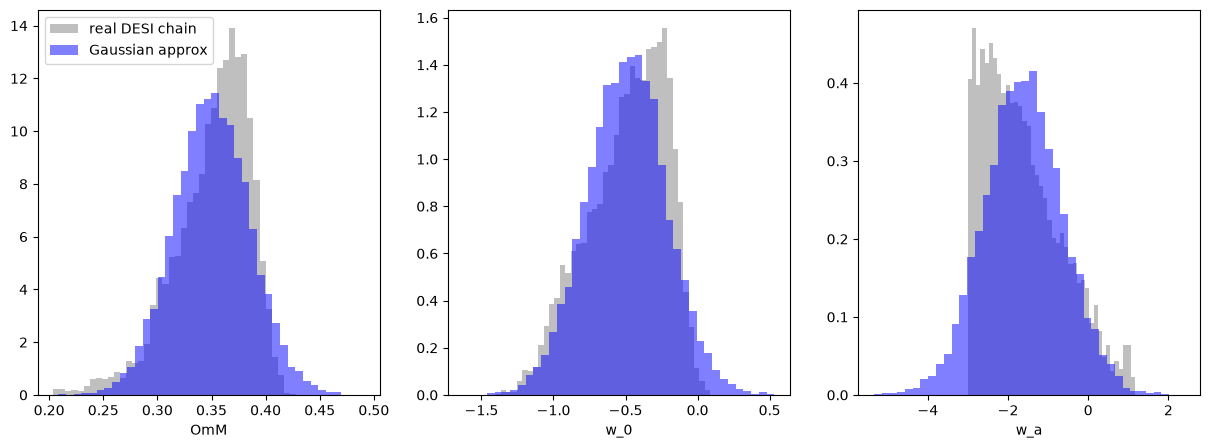

In [62]:
test_samples = desi_dist.sample(jax.random.PRNGKey(0), (10000,))

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].hist(np.array(OmM_desi), bins=40, density=True, alpha=0.5, label='real DESI chain', color='grey')
ax[0].hist(np.array(test_samples[:, 0]), bins=40, density=True, alpha=0.5, label='Gaussian approx', color='blue')
ax[0].set_xlabel('OmM'); ax[0].legend()

ax[1].hist(np.array(w_0_desi), bins=40, density=True, alpha=0.5, color='grey')
ax[1].hist(np.array(test_samples[:, 1]), bins=40, density=True, alpha=0.5, color='blue')
ax[1].set_xlabel('w_0')

ax[2].hist(np.array(w_a_desi), bins=40, density=True, alpha=0.5, color='grey')
ax[2].hist(np.array(test_samples[:, 2]), bins=40, density=True, alpha=0.5, color='blue')
ax[2].set_xlabel('w_a')
plt.savefig('desi_gaussian_check.png')

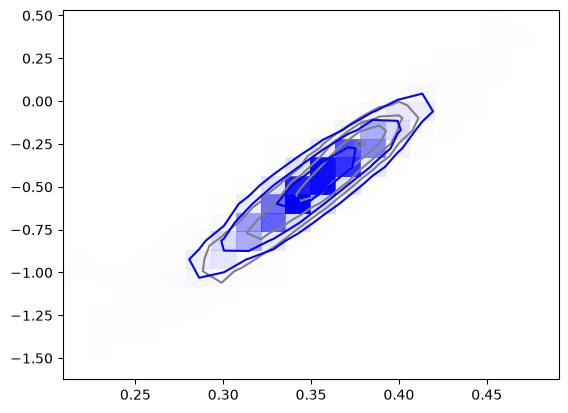

In [63]:
corner.hist2d(np.array(OmM_desi), np.array(w_0_desi), color='grey', plot_contours=True, plot_datapoints=False)
corner.hist2d(np.array(test_samples[:,0]), np.array(test_samples[:,1]), color='blue', plot_contours=True, plot_datapoints=False, fig=plt.gcf())
plt.savefig('desi_gaussian_2d_check.png')

In [65]:
def desi_only_model():
    w_0 = npr.sample('w_0', dist.Uniform(-3, 1))
    w_a = npr.sample('w_a', dist.Uniform(-3, 2))
    OmM = npr.sample('OmM', dist.Uniform(0, 1))
    log_desi = desi_dist.log_prob(jnp.array([OmM, w_0, w_a]))
    npr.factor("desi_only_factor", log_desi)

mcmc_test = MCMC(NUTS(desi_only_model), num_warmup=2000, num_samples=100000, num_chains=1)
mcmc_test.run(jax.random.PRNGKey(0))

w0_test = mcmc_test.get_samples()['w_0']
print("desi-only-model w_0 mean/std:", jnp.mean(w0_test), jnp.std(w0_test))
print("real DESI chain w_0 mean/std:", jnp.mean(w_0_desi), jnp.std(w_0_desi))

sample: 100%|██████████| 102000/102000 [00:11<00:00, 9121.93it/s, 15 steps of size 2.50e-01. acc. prob=0.89]

desi-only-model w_0 mean/std: -0.53286177 0.2369523
real DESI chain w_0 mean/std: -0.48978066 0.27135682


In [66]:
print("w_a chain range:", jnp.min(w_a_desi), jnp.max(w_a_desi))
print("w_0 chain range:", jnp.min(w_0_desi), jnp.max(w_0_desi))
print("OmM chain range:", jnp.min(OmM_desi), jnp.max(OmM_desi))

w_a chain range: -2.9992437 1.1760683
w_0 chain range: -1.4028685 0.088019304
OmM chain range: 0.20379446 0.4279765



                mean       std    median      5.0%     95.0%     n_eff     r_hat
       OmM      0.35      0.03      0.35      0.30      0.40  17947.09      1.00
       w_0     -0.53      0.24     -0.52     -0.89     -0.13  17751.44      1.00
       w_a     -1.47      0.84     -1.53     -2.95     -0.29  17364.11      1.00

Number of divergences: 0
DESI chain length: 29834


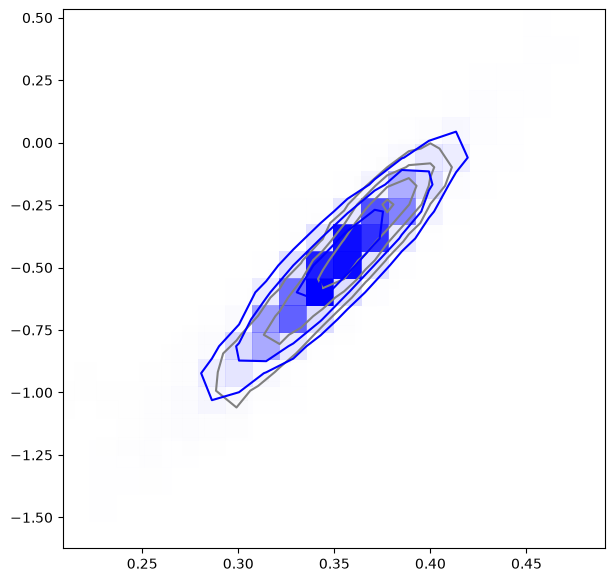

In [70]:
mcmc_test.print_summary()
print("DESI chain length:", len(w_0_desi))

test_samples = desi_dist.sample(jax.random.PRNGKey(0), (10000,))
fig, ax = plt.subplots(figsize=(7,7))
corner.hist2d(np.array(OmM_desi), np.array(w_0_desi), color='grey', plot_contours=True, plot_datapoints=False, ax=ax)
corner.hist2d(np.array(test_samples[:,0]), np.array(test_samples[:,1]), color='blue', plot_contours=True, plot_datapoints=False, fig=fig, ax=ax)
plt.savefig('desi_shape_check.png')